<a href="https://colab.research.google.com/github/Carvalho-Andre/analise_simulacoes_doutorado/blob/main/LHT_Complete_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Latent Homophily Theory (LHT) — Complete Analysis Pipeline
**Researcher:** Prof. André Sita de Carvalho  
**Institution:** Paris 1 Panthéon-Sorbonne / PRISM Laboratory  
**Central thesis:** *Entropy attracts, Homophily binds*

---
## Execution order — run cells **top to bottom, once**

| Phase | Constructo | What we measure |
|-------|-----------|-----------------|
| 0 | Setup | Install, imports, Drive mount, paths |
| 1 | YouTube diagnostic | Locate YouTube CSVs automatically |
| 2 | Data loading | SBERT embeddings + YouTube merge |
| 3 | **H(c,t)** | Semantic entropy by cluster and platform |
| 4 | **K(c)** | Kernel latent homophily + permutation test |
| 5 | **A(t)** | Temporal attraction series (4Chan harvests) |
| 6 | **Causal test** | Cross-correlation H(t)→A(t) + DES |
| 7 | Figures 1-3 | Publication-ready figures in English |
| 8 | Final analysis | Structured empirical verdict for the paper |

> **LHT vs. Liu et al. (2015):** Liu treats entropy and homophily as competing node-level mechanisms. LHT proposes a sequential causal model at the content-field level: low semantic entropy is a necessary condition for latent homophily to crystallise into persistent ties.

## PHASE 0 — Setup

In [ ]:
# ── 0.1  INSTALL DEPENDENCIES (run once per Colab session) ────────
!pip install -q sentence-transformers umap-learn hdbscan scikit-learn \
             scipy matplotlib seaborn pandas numpy
print("✅ Dependencies ready.")

✅ Dependencies ready.


In [ ]:
# ── 0.2  GLOBAL IMPORTS ───────────────────────────────────────────
import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import entropy as scipy_entropy, pearsonr, spearmanr, percentileofscore
from scipy.linalg import eigvalsh
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.cluster import KMeans
from sklearn.metrics import (homogeneity_score, completeness_score,
                              silhouette_score)
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

PLATFORM_COLORS = {
    '4Chan':   '#E63946',
    'Reddit':  '#457B9D',
    'Discord': '#2A9D8F',
    'YouTube': '#E9C46A',
}
print("✅ Imports loaded.")

✅ Imports loaded.


In [ ]:
# ── 0.3  MOUNT GOOGLE DRIVE ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord'
DADOS     = os.path.join(BASE, 'Dados Processados')
ARTIFACTS = os.path.join(BASE, 'Artifacts')
DOUTORADO = '/content/drive/MyDrive/Pesquisa_Doutorado/Coleta_Automatica_4Chan'
MYDRIVE   = '/content/drive/MyDrive'

for label, path in [('BASE', BASE), ('DADOS', DADOS),
                    ('ARTIFACTS', ARTIFACTS), ('DOUTORADO', DOUTORADO)]:
    status = '✅' if os.path.exists(path) else '❌ NOT FOUND'
    print(f'{status}  {label}: {path}')

Mounted at /content/drive
✅  BASE: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord
✅  DADOS: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Dados Processados
✅  ARTIFACTS: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Artifacts
✅  DOUTORADO: /content/drive/MyDrive/Pesquisa_Doutorado/Coleta_Automatica_4Chan


## PHASE 1 — YouTube Diagnostic
Finds your YouTube CSVs automatically. **Read the output** before proceeding.

In [ ]:
# ── 1.1  AUTO-SCAN FOR YOUTUBE FILES ────────────────────────────
print("Scanning Google Drive for YouTube data files...\n")

patterns = [
    '**/*youtube*.csv', '**/*YouTube*.csv',
    '**/*homophily*.csv', '**/*comments*.csv',
    '**/*purified*.csv', '**/*coleta_youtube*.csv',
    '**/*yt_*.csv', '**/*transcript*.csv',
]

found_yt = set()
for root in [BASE, MYDRIVE]:
    for pat in patterns:
        for fp in glob.glob(os.path.join(root, pat), recursive=True):
            found_yt.add(fp)

found_yt = sorted(found_yt)

if not found_yt:
    print("❌  No YouTube CSV files found.")
    print("   Upload your YouTube CSVs to Google Drive and re-run this cell.")
else:
    print(f"✅  {len(found_yt)} candidate file(s) found:\n")
    for fp in found_yt:
        try:
            df_peek = pd.read_csv(fp, nrows=3)
            size_kb = os.path.getsize(fp) // 1024
            n_rows  = sum(1 for _ in open(fp, encoding='utf-8', errors='ignore')) - 1
            print(f"  PATH : {fp}")
            print(f"  SIZE : {size_kb} KB  |  ROWS: ~{n_rows}")
            print(f"  COLS : {df_peek.columns.tolist()}")
            print()
        except Exception as e:
            print(f"  {fp}  [error: {e}]\n")

# Folders with youtube in name
print("--- Folders with 'youtube' / '03_YouTube' in name ---")
for root, dirs, _ in os.walk(MYDRIVE):
    for d in dirs:
        if 'youtube' in d.lower() or '03_yt' in d.lower():
            full = os.path.join(root, d)
            items = os.listdir(full)
            print(f"  {full}  →  {items[:8]}")


Scanning Google Drive for YouTube data files...

✅  12 candidate file(s) found:

  PATH : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Extremism/youtube_purified_dataset.csv
  SIZE : 1 KB  |  ROWS: ~11
  COLS : ['video_id', 'title', 'channel', 'collected_at', 'theme']

  PATH : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Misinformation/youtube_purified_dataset.csv
  SIZE : 3 KB  |  ROWS: ~25
  COLS : ['video_id', 'title', 'channel', 'collected_at', 'theme']

  PATH : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Politics/youtube_purified_dataset.csv
  SIZE : 3 KB  |  ROWS: ~27
  COLS : ['video_id', 'title', 'channel', 'collected_at', 'theme']

  PATH : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Dados Processados/coleta_youtube_macro.csv
  SIZE : 2 KB  |  ROWS: ~10
  COLS : ['video_id', 'titulo', 'canal', 'data_publicacao', 'link', 'transcricao_texto']

  PATH : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e

## PHASE 2 — Data Loading
Two sub-sections: (A) main corpus SBERT embeddings, (B) YouTube merge.
**Before running 2-B**, check the paths printed in Phase 1 and update `YT_PATHS` if needed.

In [ ]:
# ── 2-A  LOAD SBERT EMBEDDINGS + METADATA ────────────────────────
# These are the pre-computed embeddings (3245 texts × 384 dims).
# The KMeans model is also fitted here so YouTube can reuse it.

EMB_CACHE = os.path.join(ARTIFACTS, 'EmbeddingCache')

# Auto-locate the .npy and .meta.csv files
npy_candidates = sorted(glob.glob(os.path.join(EMB_CACHE, '*.npy')))
meta_candidates = sorted(glob.glob(os.path.join(EMB_CACHE, '*.meta.csv')))

print("Embedding cache files found:")
for f in npy_candidates:  print(f"  npy : {f}")
for f in meta_candidates: print(f"  meta: {f}")

if not npy_candidates or not meta_candidates:
    raise FileNotFoundError(
        "Embedding cache not found. Check ARTIFACTS path or re-run embedding phase."
    )

EMB_PATH  = npy_candidates[0]
META_PATH = meta_candidates[0]

emb  = np.load(EMB_PATH)
meta = pd.read_csv(META_PATH)

# Ensure standard column names
if 'network' not in meta.columns:
    # Try common alternatives
    for alt in ['platform','source','board']:
        if alt in meta.columns:
            meta = meta.rename(columns={alt: 'network'})
            break

emb_norm = normalize(emb, norm='l2')

assert len(emb) == len(meta), "❌ Embeddings and metadata row count mismatch!"
print(f"\n✅  Embeddings loaded: {emb.shape}")
print(f"✅  Metadata: {len(meta)} rows | columns: {meta.columns.tolist()}")
print(f"\nPlatform distribution:")
print(meta['network'].value_counts())

Embedding cache files found:
  npy : /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Artifacts/EmbeddingCache/emb_sentence-transformers_all-MiniLM-L6-v2_N3245.npy
  meta: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Artifacts/EmbeddingCache/emb_sentence-transformers_all-MiniLM-L6-v2_N3245.meta.csv

✅  Embeddings loaded: (3245, 384)
✅  Metadata: 3245 rows | columns: ['text', 'network', 'subgroup', 'source_id']

Platform distribution:
network
4Chan      1200
Discord    1200
Reddit      845
Name: count, dtype: int64


In [ ]:
# ── 2-B  YOUTUBE LOADER (adaptive, schema-tolerant) ──────────────
#
# Option A (recommended): leave YT_PATHS = {} and let auto-discovery
#   fill it from Phase 1 results.
# Option B: paste exact paths from Phase 1 output, e.g.:
#   YT_PATHS = {
#       'Politics'      : '/content/drive/MyDrive/.../politics.csv',
#       'Extremism'     : '/content/drive/MyDrive/.../extremism.csv',
#       'Misinformation': '/content/drive/MyDrive/.../misinfo.csv',
#   }
# ─────────────────────────────────────────────────────────────────
YT_PATHS = {}   # ← paste paths here if auto-discovery fails

TEXT_COL_CANDIDATES = [
    'comment', 'texto', 'text', 'transcript', 'transcricao_texto',
    'body', 'content', 'comentario', 'comment_text',
]

def detect_text_col(df):
    for c in TEXT_COL_CANDIDATES:
        if c in df.columns:
            return c
    str_cols = df.select_dtypes(include='object').columns.tolist()
    if str_cols:
        best = max(str_cols, key=lambda c: df[c].dropna().astype(str).str.len().mean())
        print(f"    ⚠️  No standard text column — using '{best}' (longest strings)")
        return best
    raise ValueError("No text column found in CSV")

# Auto-discovery if YT_PATHS is empty
if not YT_PATHS:
    print("Auto-discovering YouTube files...")
    yt_patterns = ['**/*youtube*.csv','**/*YouTube*.csv','**/*homophily*.csv',
                   '**/*comments*.csv','**/*purified*.csv','**/*coleta_youtube*.csv']
    disc = set()
    for root in [BASE, MYDRIVE]:
        for pat in yt_patterns:
            for fp in glob.glob(os.path.join(root, pat), recursive=True):
                disc.add(fp)
    for fp in sorted(disc):
        label = os.path.basename(os.path.dirname(fp))
        YT_PATHS[label] = fp
        print(f"  Found [{label}]: {fp}")

yt_frames = []
for theme, path in YT_PATHS.items():
    if not os.path.exists(path):
        print(f"  ⚠️  Not found: {path}")
        continue
    try:
        df_tmp = pd.read_csv(path)
        tcol = detect_text_col(df_tmp)
        df_tmp = df_tmp.rename(columns={tcol: 'text'})
        df_tmp['network']   = 'YouTube'
        df_tmp['subgroup']  = theme
        df_tmp['source_id'] = theme + '_' + df_tmp.index.astype(str)
        yt_frames.append(df_tmp[['text','network','subgroup','source_id']])
        print(f"  ✅  [{theme}]  {len(df_tmp)} rows  (col='{tcol}')")
    except Exception as e:
        print(f"  ❌  [{theme}]  {e}")

# ── Merge or continue without YouTube ──────────────────────────────
if yt_frames:
    from sentence_transformers import SentenceTransformer
    df_yt = pd.concat(yt_frames, ignore_index=True)
    df_yt['text'] = df_yt['text'].fillna('').astype(str).str.strip()
    df_yt = df_yt[df_yt['text'].str.len() >= 10].reset_index(drop=True)
    print(f"\n📊  YouTube comments after cleaning: {len(df_yt)}")

    print("Encoding YouTube comments with SBERT...")
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    emb_yt      = embedder.encode(df_yt['text'].tolist(), batch_size=128,
                                   show_progress_bar=True, convert_to_numpy=True)
    emb_yt_norm = normalize(emb_yt, norm='l2')

    # KMeans is fitted in Phase 3 — store YouTube embeddings for later assignment
    _yt_pending = True
    print("✅  YouTube embeddings ready. Will be assigned to clusters in Phase 3.")
else:
    _yt_pending = False
    df_yt = pd.DataFrame(columns=['text','network','subgroup','source_id'])
    emb_yt_norm = np.empty((0, emb_norm.shape[1]))
    print("⚠️  No YouTube data loaded. Analysis continues with 3 platforms.")
    print("   To add YouTube: paste the correct paths into YT_PATHS above and re-run.")


Auto-discovering YouTube files...
  Found [Extremism]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Extremism/youtube_purified_dataset.csv
  Found [Misinformation]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Misinformation/youtube_purified_dataset.csv
  Found [Politics]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/03_YouTube/Politics/youtube_purified_dataset.csv
  Found [Dados Processados]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Dados Processados/coleta_youtube_macro.csv
  Found [Dados Processados]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Dados Processados/youtube_comments_homophily.csv
  Found [Dados Processados]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Dados Processados/youtube_purified_dataset.csv
  Found [Extremism]: /content/drive/MyDrive/Pesquisa 4Chan, Reddit e Discord/Youtube/Extremism/youtube_comments_homophily.csv
  Found [Extremism]: /content/drive/MyDrive/Pesquisa 4Cha

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅  YouTube embeddings ready. Will be assigned to clusters in Phase 3.


## PHASE 3 — H(c,t): Semantic Entropy

**Formal definition (LHT):**

$$H(c, t) = -\sum_{p \in P} \pi_p(c, t) \log_2 \pi_p(c, t)$$

$\pi_p(c,t)$ = proportion of platform $p$ in cluster $c$ at time $t$.

**Interpretation:** High H → mixed cluster (attraction phase). Low H → homogeneous cluster (homophilic cohesion phase).

In [ ]:
# ── 3.1  K-MEANS CLUSTERING (K=3, validated in prior notebooks) ──
K_MACRO = 3

km = KMeans(n_clusters=K_MACRO, random_state=SEED, n_init=20)
meta['cluster_macro'] = km.fit_predict(emb_norm)

sil = silhouette_score(emb_norm, meta['cluster_macro'],
                        metric='cosine', sample_size=2000)
hom = homogeneity_score(meta['network'], meta['cluster_macro'])
com = completeness_score(meta['network'], meta['cluster_macro'])

print(f"✅  KMeans K={K_MACRO} fitted")
print(f"   Silhouette (cosine) : {sil:.4f}")
print(f"   Homogeneity         : {hom:.4f}")
print(f"   Completeness        : {com:.4f}")
print()
print(meta.groupby(['cluster_macro','network']).size().unstack(fill_value=0))

# ── Assign YouTube to clusters now that km is fitted ─────────────
if _yt_pending and len(emb_yt_norm):
    df_yt['cluster_macro'] = km.predict(emb_yt_norm)
    print("\n✅  YouTube assigned to clusters:")
    print(df_yt['cluster_macro'].value_counts().sort_index())

# ── Build extended META and EMB (all 4 platforms) ─────────────────
if len(df_yt):
    META = pd.concat(
        [meta, df_yt[['text','network','subgroup','source_id','cluster_macro']]],
        ignore_index=True
    )
    EMB = np.vstack([emb_norm, emb_yt_norm])
else:
    META = meta.copy()
    EMB  = emb_norm.copy()

assert len(META) == len(EMB), "❌ META/EMB alignment error"
print(f"\n✅  Extended corpus: {len(META):,} observations")
print(META['network'].value_counts())

✅  KMeans K=3 fitted
   Silhouette (cosine) : 0.1432
   Homogeneity         : 0.5497
   Completeness        : 0.5538

network        4Chan  Discord  Reddit
cluster_macro                        
0                335       31     423
1                  7     1154       0
2                858       15     422

✅  YouTube assigned to clusters:
cluster_macro
0    68
2     9
Name: count, dtype: int64

✅  Extended corpus: 3,322 observations
network
4Chan      1200
Discord    1200
Reddit      845
YouTube      77
Name: count, dtype: int64


In [ ]:
# ── 3.2  SHANNON ENTROPY H(c) PER CLUSTER ────────────────────────
def platform_entropy(grp):
    counts = grp['network'].value_counts(normalize=True)
    return float(scipy_entropy(counts.values, base=2))

entropy_rows = []
for cid, grp in META.groupby('cluster_macro'):
    H   = platform_entropy(grp)
    dom = grp['network'].value_counts().index[0]
    row = {'cluster': cid, 'size': len(grp),
           'dominant_platform': dom, 'H_platform': round(H,4)}
    row.update(grp['network'].value_counts().to_dict())
    entropy_rows.append(row)

df_entropy = pd.DataFrame(entropy_rows).sort_values('H_platform', ascending=False)
print("📊  Shannon Entropy H(c) per cluster:")
print(df_entropy.to_string(index=False))

📊  Shannon Entropy H(c) per cluster:
 cluster  size dominant_platform  H_platform  Reddit  4Chan  YouTube  Discord
       0   857            Reddit      1.4958   423.0    335     68.0       31
       2  1304             4Chan      1.0477   422.0    858      9.0       15
       1  1161           Discord      0.0531     NaN      7      NaN     1154


In [ ]:
# ── 3.3  VON NEUMANN ENTROPY (geometric measure) ─────────────────
def von_neumann_entropy(emb_sub, gamma=1.0, max_n=500):
    """S(ρ) = -Tr(ρ log ρ),  ρ = K/Tr(K),  K = RBF kernel"""
    if len(emb_sub) > max_n:
        idx = np.random.choice(len(emb_sub), max_n, replace=False)
        emb_sub = emb_sub[idx]
    K   = rbf_kernel(emb_sub, gamma=gamma)
    rho = K / np.trace(K)
    ev  = eigvalsh(rho)
    ev  = ev[ev > 1e-10]
    return float(-np.sum(ev * np.log(ev)))

print("Computing Von Neumann Entropy per cluster...")
vne_rows = []
for cid, grp in META.groupby('cluster_macro'):
    idx = grp.index.values
    S   = von_neumann_entropy(EMB[idx])
    vne_rows.append({'cluster': cid, 'VNE': round(S,4), 'size': len(grp)})

df_vne    = pd.DataFrame(vne_rows)
df_entropy = df_entropy.merge(df_vne[['cluster','VNE']], on='cluster')

print("\n📊  H(c) + Von Neumann Entropy:")
print(df_entropy[['cluster','size','dominant_platform','H_platform','VNE']].to_string(index=False))
print()
print("Interpretation: low VNE → tight semantic geometry → latent homophily signal")

Computing Von Neumann Entropy per cluster...

📊  H(c) + Von Neumann Entropy:
 cluster  size dominant_platform  H_platform    VNE
       0   857            Reddit      1.4958 5.2368
       2  1304             4Chan      1.0477 5.2949
       1  1161           Discord      0.0531 4.5493

Interpretation: low VNE → tight semantic geometry → latent homophily signal


## PHASE 4 — K(c): Kernel Latent Homophily

**Formal definition (LHT):**

$$\mathcal{K}(c) = \frac{1}{|c|^2}\sum_{i,j\in c}k(x_i,x_j) - \frac{2}{|c|\cdot N}\sum_{i\in c,\,j\notin c}k(x_i,x_j)$$

$\mathcal{K}(c)>0$ means intra-cluster semantic similarity exceeds the background → **latent homophily detected before any explicit social tie exists**.

In [ ]:
# ── 4.1  KERNEL HOMOPHILY SCORE ───────────────────────────────────
def kernel_homophily(emb_all, mask, gamma=1.0, max_s=300):
    idx_in  = np.where(mask)[0]
    idx_out = np.where(~mask)[0]
    if len(idx_in)  > max_s: idx_in  = np.random.choice(idx_in,  max_s, replace=False)
    if len(idx_out) > max_s: idx_out = np.random.choice(idx_out, max_s, replace=False)
    E_in, E_out = emb_all[idx_in], emb_all[idx_out]
    K_intra = rbf_kernel(E_in, E_in,  gamma=gamma).mean()
    K_inter = rbf_kernel(E_in, E_out, gamma=gamma).mean()
    return float(K_intra - K_inter), float(K_intra), float(K_inter)

print("Computing Kernel Homophily Score per cluster...\n")
hom_rows = []
for cid in sorted(META['cluster_macro'].unique()):
    mask = (META['cluster_macro'] == cid).values
    kh, ki, ko = kernel_homophily(EMB, mask)
    dom  = META[mask]['network'].value_counts().index[0]
    hom_rows.append({'cluster': cid, 'dominant': dom, 'n': mask.sum(),
                     'K_homophily': round(kh,6),
                     'K_intra': round(ki,6), 'K_inter': round(ko,6),
                     'homophily_detected': kh > 0})
    icon = '✅' if kh > 0 else '❌'
    print(f"{icon} Cluster {cid} [{dom:>8}]  n={mask.sum():5d}  "
          f"K(c)={kh:+.6f}  K_intra={ki:.6f}  K_inter={ko:.6f}")

df_homophily = pd.DataFrame(hom_rows)
print(f"\nAll K(c) > 0: {df_homophily['homophily_detected'].all()}")

Computing Kernel Homophily Score per cluster...

✅ Cluster 0 [  Reddit]  n=  857  K(c)=+0.010407  K_intra=0.167179  K_inter=0.156772
✅ Cluster 1 [ Discord]  n= 1161  K(c)=+0.135157  K_intra=0.295611  K_inter=0.160453
✅ Cluster 2 [   4Chan]  n= 1304  K(c)=+0.033963  K_intra=0.191749  K_inter=0.157786

All K(c) > 0: True


In [ ]:
# ── 4.2  PERMUTATION TEST (statistical significance) ─────────────
N_PERM = 500   # increase to 1000 for the final paper

print(f"Running permutation test (n_perm={N_PERM})...\n")
perm_rows = []
for cid in sorted(META['cluster_macro'].unique()):
    mask_obs = (META['cluster_macro'] == cid).values
    k_obs, _, _ = kernel_homophily(EMB, mask_obs)
    null = [kernel_homophily(EMB, np.random.permutation(mask_obs))[0]
            for _ in range(N_PERM)]
    p_val = 1 - percentileofscore(null, k_obs) / 100
    perm_rows.append({'cluster': cid, 'K_obs': k_obs,
                      'null_mean': np.mean(null), 'null_std': np.std(null),
                      'p_value': round(p_val, 4)})
    sig = ('***' if p_val < 0.001 else '**' if p_val < 0.01
           else '*' if p_val < 0.05 else 'n.s.')
    print(f"Cluster {cid}  K_obs={k_obs:+.6f}  p={p_val:.4f} {sig}")

df_perm = pd.DataFrame(perm_rows)
df_homophily = df_homophily.merge(df_perm[['cluster','p_value']], on='cluster')
print("\n✅  Permutation test complete.")

Running permutation test (n_perm=500)...

Cluster 0  K_obs=+0.008434  p=0.0080 **
Cluster 1  K_obs=+0.143335  p=0.0000 ***
Cluster 2  K_obs=+0.029263  p=0.0000 ***

✅  Permutation test complete.


## PHASE 5 — A(t): Temporal Attraction

**This constructo was missing in all previous notebooks — it is the causal heart of LHT.**

$$A(t)=\frac{\Delta N(t)}{\Delta t}, \qquad H_{\text{lex}}(t)=-\sum_w p_w(t)\log_2 p_w(t)$$

**LHT hypothesis:** $dH/dt < 0$ precedes $dA/dt > 0$ — semantic entropy collapses *before* inflow grows.

In [ ]:
# ── 5.1  LOAD 4CHAN HARVEST FILES (temporal data) ─────────────────
harvest_files = sorted(glob.glob(os.path.join(DOUTORADO, '4chan_harvest_*.csv')))
print(f"Found {len(harvest_files)} harvest files.")

if not harvest_files:
    print("⚠️  No harvest files found. Phase 5 and 6 will be skipped.")
    _has_temporal = False
    df_temporal = pd.DataFrame()
else:
    _has_temporal = True
    USECOLS = ['board','text','replies','images','date_collected','unix_time','id']
    frames = []
    for fp in harvest_files:
        try:
            df_tmp = pd.read_csv(fp)
            # Keep only columns that exist
            cols = [c for c in USECOLS if c in df_tmp.columns]
            frames.append(df_tmp[cols])
        except Exception as e:
            print(f"  ⚠️  {fp}: {e}")

    df_temporal = pd.concat(frames, ignore_index=True)

    # Parse dates — handle multiple formats
    for dcol in ['date_collected','date']:
        if dcol in df_temporal.columns:
            df_temporal['date_dt'] = pd.to_datetime(
                df_temporal[dcol], errors='coerce', utc=False)
            break
    if 'unix_time' in df_temporal.columns and df_temporal['date_dt'].isna().all():
        df_temporal['date_dt'] = pd.to_datetime(
            df_temporal['unix_time'], unit='s', errors='coerce')

    df_temporal['date'] = df_temporal['date_dt'].dt.date
    if 'id' in df_temporal.columns:
        df_temporal = df_temporal.drop_duplicates(subset=['id','date'])

    print(f"✅  Temporal data: {len(df_temporal):,} unique records")
    print(f"   Period : {df_temporal['date'].min()} → {df_temporal['date'].max()}")
    if 'board' in df_temporal.columns:
        print(f"   Boards : {df_temporal['board'].unique()}")

Found 24 harvest files.
✅  Temporal data: 14,104 unique records
   Period : 2026-02-07 → 2026-02-28
   Boards : ['/pol/' '/news/' '/biz/' '/g/']


In [ ]:
# ── 5.2  DAILY LEXICAL ENTROPY H_lex(t) ──────────────────────────
def daily_lexical_entropy(texts, top_n=50):
    texts = [str(t) for t in texts if isinstance(t,str) and len(str(t)) > 5]
    if len(texts) < 5: return np.nan
    vec = CountVectorizer(max_features=top_n, stop_words='english',
                          min_df=2, token_pattern=r'\b[a-z]{3,}\b')
    try:
        X    = vec.fit_transform(texts)
        freq = np.asarray(X.sum(axis=0)).flatten()
        freq = freq[freq > 0]
        return float(scipy_entropy(freq / freq.sum(), base=2))
    except:
        return np.nan

if _has_temporal:
    print("Computing daily lexical entropy...")
    ent_rows = []
    grp_cols = ['board','date'] if 'board' in df_temporal.columns else ['date']
    for keys, grp in df_temporal.groupby(grp_cols):
        board = keys[0] if isinstance(keys, tuple) else 'all'
        date  = keys[1] if isinstance(keys, tuple) else keys
        tcol  = 'text' if 'text' in grp.columns else grp.columns[0]
        H_t   = daily_lexical_entropy(grp[tcol].tolist())
        ent_rows.append({'board': board, 'date': date,
                         'H_lexical': H_t, 'n_threads': len(grp)})
    df_ent_time = pd.DataFrame(ent_rows)
    df_ent_time['date'] = pd.to_datetime(df_ent_time['date'])
    print(f"✅  {len(df_ent_time)} daily observations computed.")
    print(df_ent_time.groupby('board')['H_lexical'].describe().round(3))
else:
    df_ent_time = pd.DataFrame()
    print("⚠️  Skipped (no harvest files).")

Computing daily lexical entropy...
✅  80 daily observations computed.
        count   mean    std    min    25%    50%    75%    max
board                                                         
/biz/    20.0  4.418  0.109  4.268  4.338  4.404  4.440  4.723
/g/      20.0  4.375  0.048  4.275  4.349  4.371  4.414  4.445
/news/   20.0  5.229  0.010  5.208  5.222  5.229  5.239  5.243
/pol/    20.0  4.489  0.142  4.150  4.404  4.475  4.553  4.751


In [ ]:
# ── 5.3  BUILD CAUSAL DATASET A(t) + H(t) ────────────────────────
if _has_temporal and len(df_ent_time):
    agg_cols = {'n_threads': ('id','count')} if 'id' in df_temporal.columns else {}
    if 'replies' in df_temporal.columns:
        agg_cols['total_replies'] = ('replies','sum')
        agg_cols['mean_replies']  = ('replies','mean')

    grp_cols = ['board','date'] if 'board' in df_temporal.columns else ['date']
    df_daily = df_temporal.groupby(grp_cols).agg(**agg_cols).reset_index()
    df_daily['date'] = pd.to_datetime(df_daily['date'])

    merge_cols = ['board','date'] if 'board' in df_daily.columns else ['date']
    df_causal = df_daily.merge(
        df_ent_time[merge_cols + ['H_lexical']], on=merge_cols, how='left'
    ).sort_values(merge_cols)

    smooth_group = 'board' if 'board' in df_causal.columns else None
    roll_fn = lambda x: x.rolling(3, center=True, min_periods=1).mean()
    if smooth_group:
        df_causal['H_smooth'] = df_causal.groupby(smooth_group)['H_lexical'].transform(roll_fn)
        if 'total_replies' in df_causal.columns:
            df_causal['A_smooth'] = df_causal.groupby(smooth_group)['total_replies'].transform(roll_fn)
    else:
        df_causal['H_smooth'] = roll_fn(df_causal['H_lexical'])
        if 'total_replies' in df_causal.columns:
            df_causal['A_smooth'] = roll_fn(df_causal['total_replies'])

    print("✅  Causal dataset built:")
    display_cols = [c for c in ['date','board','H_lexical','H_smooth','total_replies','A_smooth']
                    if c in df_causal.columns]
    print(df_causal[display_cols].head(10).to_string(index=False))
else:
    df_causal = pd.DataFrame()
    print("⚠️  Skipped.")

✅  Causal dataset built:
      date board  H_lexical  H_smooth  total_replies    A_smooth
2026-02-07 /biz/   4.295373  4.317447           4711 5063.000000
2026-02-08 /biz/   4.339520  4.383364           5415 5259.000000
2026-02-09 /biz/   4.515198  4.394287           5651 5796.333333
2026-02-10 /biz/   4.328143  4.406202           6323 5866.333333
2026-02-11 /biz/   4.375266  4.380425           5625 5641.000000
2026-02-12 /biz/   4.437866  4.410437           4975 5565.333333
2026-02-13 /biz/   4.418180  4.465000           6096 5552.666667
2026-02-14 /biz/   4.538956  4.559917           5587 5603.000000
2026-02-15 /biz/   4.722616  4.565634           5126 5830.666667
2026-02-16 /biz/   4.435332  4.528509           6779 6096.000000


## PHASE 6 — Causal Test: H(t) → A(t) + Dominant Eigenvalue Share

In [ ]:
# ── 6.1  CROSS-CORRELATION H(t) × A(t) ───────────────────────────
df_xcorr = pd.DataFrame()

if _has_temporal and 'A_smooth' in df_causal.columns and len(df_causal) >= 6:
    MAX_LAG = 5
    print(f"Cross-correlation H(t) × A(t) per board (max_lag={MAX_LAG} days):\n")
    xcorr_rows = []
    board_col = 'board' if 'board' in df_causal.columns else None

    groups = (df_causal.groupby('board') if board_col
              else [('all', df_causal)])

    for board, grp in groups:
        grp = grp.dropna(subset=['H_smooth','A_smooth']).sort_values('date')
        if len(grp) < 8: continue
        H = (grp['H_smooth'].values - grp['H_smooth'].mean()) / (grp['H_smooth'].std() + 1e-9)
        A = (grp['A_smooth'].values - grp['A_smooth'].mean()) / (grp['A_smooth'].std() + 1e-9)
        best_r, best_lag, best_p = 0, 0, 1.0
        for lag in range(-MAX_LAG, MAX_LAG + 1):
            if lag > 0:
                r, p = pearsonr(H[:-lag], A[lag:])
            elif lag < 0:
                r, p = pearsonr(H[-lag:], A[:lag])
            else:
                r, p = pearsonr(H, A)
            if abs(r) > abs(best_r):
                best_r, best_lag, best_p = r, lag, p
        sig   = ('***' if best_p < 0.001 else '**' if best_p < 0.01
                 else '*' if best_p < 0.05 else 'n.s.')
        interp = ('H→A (LHT ✅)' if best_lag > 0
                  else 'Simultaneous' if best_lag == 0 else 'A→H (reversed)')
        xcorr_rows.append({'board': board, 'best_lag_days': best_lag,
                            'r': round(best_r,4), 'p': round(best_p,4),
                            'sig': sig, 'interpretation': interp})
        print(f"  Board {board:6}  lag={best_lag:+2d}d  r={best_r:+.4f} {sig}  {interp}")
    df_xcorr = pd.DataFrame(xcorr_rows)
    print("\n✅  Cross-correlation complete.")
else:
    print("⚠️  Cross-correlation skipped (insufficient temporal data).")

Cross-correlation H(t) × A(t) per board (max_lag=5 days):

  Board /biz/   lag=+2d  r=+0.4595 n.s.  H→A (LHT ✅)
  Board /g/     lag=-5d  r=-0.4736 n.s.  A→H (reversed)
  Board /news/  lag=+2d  r=+0.8880 ***  H→A (LHT ✅)
  Board /pol/   lag=+2d  r=-0.6413 **  H→A (LHT ✅)

✅  Cross-correlation complete.


In [ ]:
# ── 6.2  DOMINANT EIGENVALUE SHARE (DES) ─────────────────────────
def dominant_eigenvalue_share(emb_sub, gamma=1.0, max_n=400):
    """DES = λ_max / Tr(K). High → tight cluster. Low → diffuse / artefact."""
    if len(emb_sub) > max_n:
        idx = np.random.choice(len(emb_sub), max_n, replace=False)
        emb_sub = emb_sub[idx]
    K  = rbf_kernel(emb_sub, gamma=gamma)
    ev = np.sort(eigvalsh(K))[::-1]
    ev = ev[ev > 0]
    return float(ev[0] / ev.sum())

print("Computing Dominant Eigenvalue Share per cluster...\n")
des_rows = []
for cid, grp in META.groupby('cluster_macro'):
    idx = grp.index.values
    DES = dominant_eigenvalue_share(EMB[idx])
    dom = grp['network'].value_counts().index[0]
    H   = df_entropy[df_entropy['cluster'] == cid]['H_platform'].values[0]
    quality = ('🟢 Genuine cluster' if DES > 0.15
               else '🟡 Moderate' if DES > 0.05 else '🔴 Possible artefact')
    des_rows.append({'cluster': cid, 'dominant': dom, 'n': len(idx),
                     'DES': round(DES,4), 'H_platform': H})
    print(f"  Cluster {cid} [{dom:>8}]  DES={DES:.4f}  H={H:.4f}  {quality}")

df_des = pd.DataFrame(des_rows)

# Consolidated summary table
df_summary = (
    df_entropy[['cluster','size','dominant_platform','H_platform','VNE']]
    .merge(df_homophily[['cluster','K_homophily','p_value']], on='cluster')
    .merge(df_des[['cluster','DES']], on='cluster')
    .rename(columns={'cluster':'Cluster','size':'N',
                     'dominant_platform':'Platform',
                     'H_platform':'H(c) [bits]',
                     'K_homophily':'K(c)',
                     'p_value':'p-value'})
)
print("\n📋  Consolidated summary:")
print(df_summary.to_string(index=False))

Computing Dominant Eigenvalue Share per cluster...

  Cluster 0 [  Reddit]  DES=0.1668  H=1.4958  🟢 Genuine cluster
  Cluster 1 [ Discord]  DES=0.3103  H=0.0531  🟢 Genuine cluster
  Cluster 2 [   4Chan]  DES=0.1904  H=1.0477  🟢 Genuine cluster

📋  Consolidated summary:
 Cluster    N Platform  H(c) [bits]    VNE     K(c)  p-value    DES
       0  857   Reddit       1.4958 5.2368 0.010407    0.008 0.1668
       2 1304    4Chan       1.0477 5.2949 0.033963    0.000 0.1904
       1 1161  Discord       0.0531 4.5493 0.135157    0.000 0.3103


## PHASE 7 — Publication Figures (English)

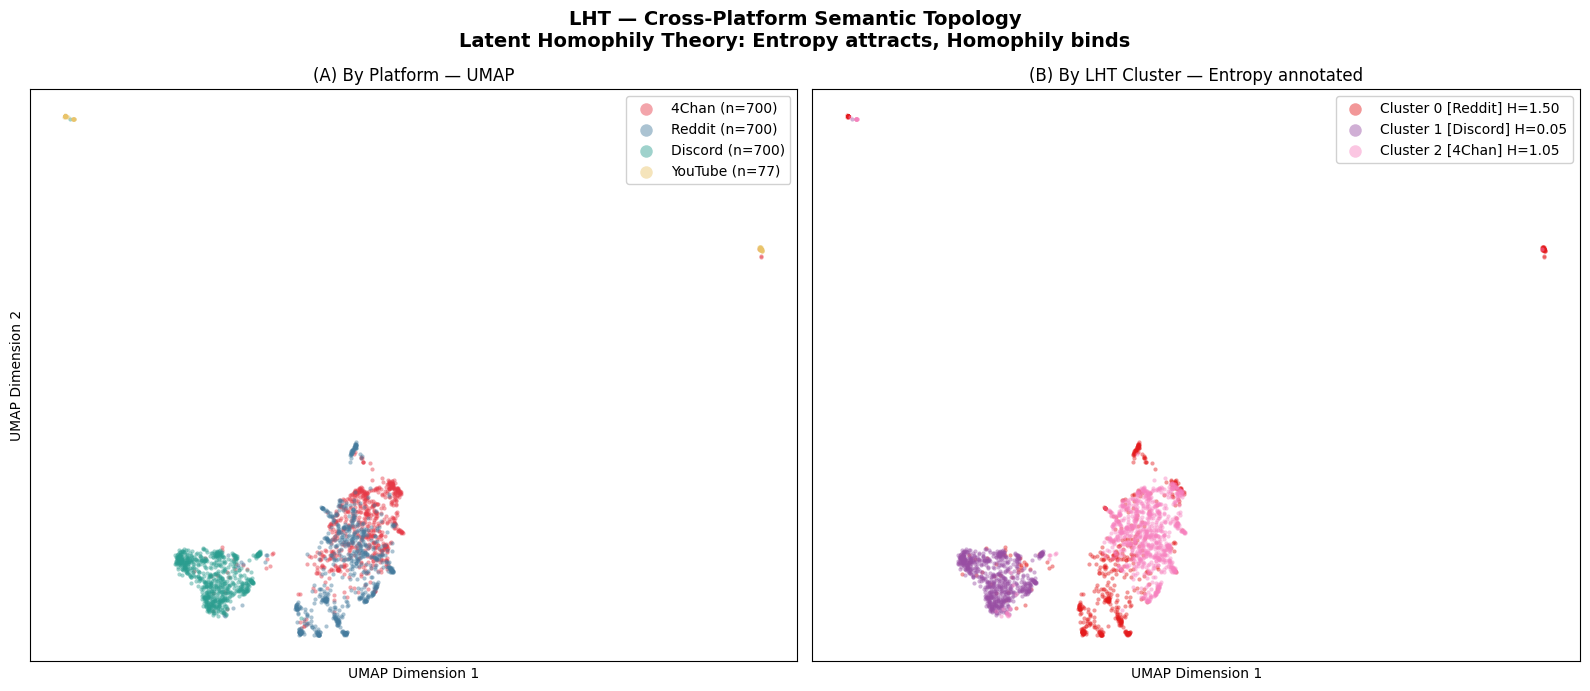

✅  Figure 1 saved.


In [ ]:
# ── FIGURE 1 — SEMANTIC TOPOLOGY (UMAP / t-SNE) ──────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=SEED,
                        metric='cosine', n_neighbors=30, min_dist=0.1)
    USE_UMAP = True
except ImportError:
    USE_UMAP = False

np.random.seed(SEED)
MAX_PER = 700
idx_list = []
for plat in META['network'].unique():
    idx_p = META.index[META['network'] == plat].tolist()
    if len(idx_p) > MAX_PER:
        idx_p = np.random.choice(idx_p, MAX_PER, replace=False).tolist()
    idx_list.extend(idx_p)
idx_plot   = np.array(idx_list)
meta_plot  = META.iloc[idx_plot].reset_index(drop=True)
emb_plot   = EMB[idx_plot]

if USE_UMAP:
    proj2d     = reducer.fit_transform(emb_plot)
    proj_label = 'UMAP'
else:
    proj2d     = TSNE(n_components=2, random_state=SEED, metric='cosine',
                      perplexity=40, n_iter=1000).fit_transform(emb_plot)
    proj_label = 't-SNE'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'LHT — Cross-Platform Semantic Topology\n'
    'Latent Homophily Theory: Entropy attracts, Homophily binds',
    fontsize=14, fontweight='bold'
)

# Panel A — by platform
ax = axes[0]
for platform, color in PLATFORM_COLORS.items():
    mask = meta_plot['network'] == platform
    if not mask.any(): continue
    ax.scatter(proj2d[mask,0], proj2d[mask,1], c=color,
               label=f'{platform} (n={mask.sum()})',
               alpha=0.45, s=9, linewidths=0)
ax.set_title(f'(A) By Platform — {proj_label}', fontsize=12)
ax.legend(markerscale=3, framealpha=0.9, fontsize=10)
ax.set_xlabel(f'{proj_label} Dimension 1', fontsize=10)
ax.set_ylabel(f'{proj_label} Dimension 2', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

# Panel B — by LHT cluster
ax = axes[1]
cpal = plt.cm.Set1(np.linspace(0, 0.8, int(META['cluster_macro'].nunique())))
for cid in sorted(META['cluster_macro'].unique()):
    mask = meta_plot['cluster_macro'] == cid
    if not mask.any(): continue
    dom   = meta_plot[mask]['network'].value_counts().index[0]
    H_row = df_entropy[df_entropy['cluster'] == cid]
    H_str = f"H={H_row['H_platform'].values[0]:.2f}" if len(H_row) else ''
    ax.scatter(proj2d[mask,0], proj2d[mask,1], c=[cpal[cid]],
               label=f'Cluster {cid} [{dom}] {H_str}',
               alpha=0.45, s=9, linewidths=0)
ax.set_title('(B) By LHT Cluster — Entropy annotated', fontsize=12)
ax.legend(markerscale=3, framealpha=0.9, fontsize=10)
ax.set_xlabel(f'{proj_label} Dimension 1', fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
for ext in ('pdf','png'):
    plt.savefig(f'{MYDRIVE}/LHT_Fig1_SemanticTopology.{ext}',
                dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 1 saved.")

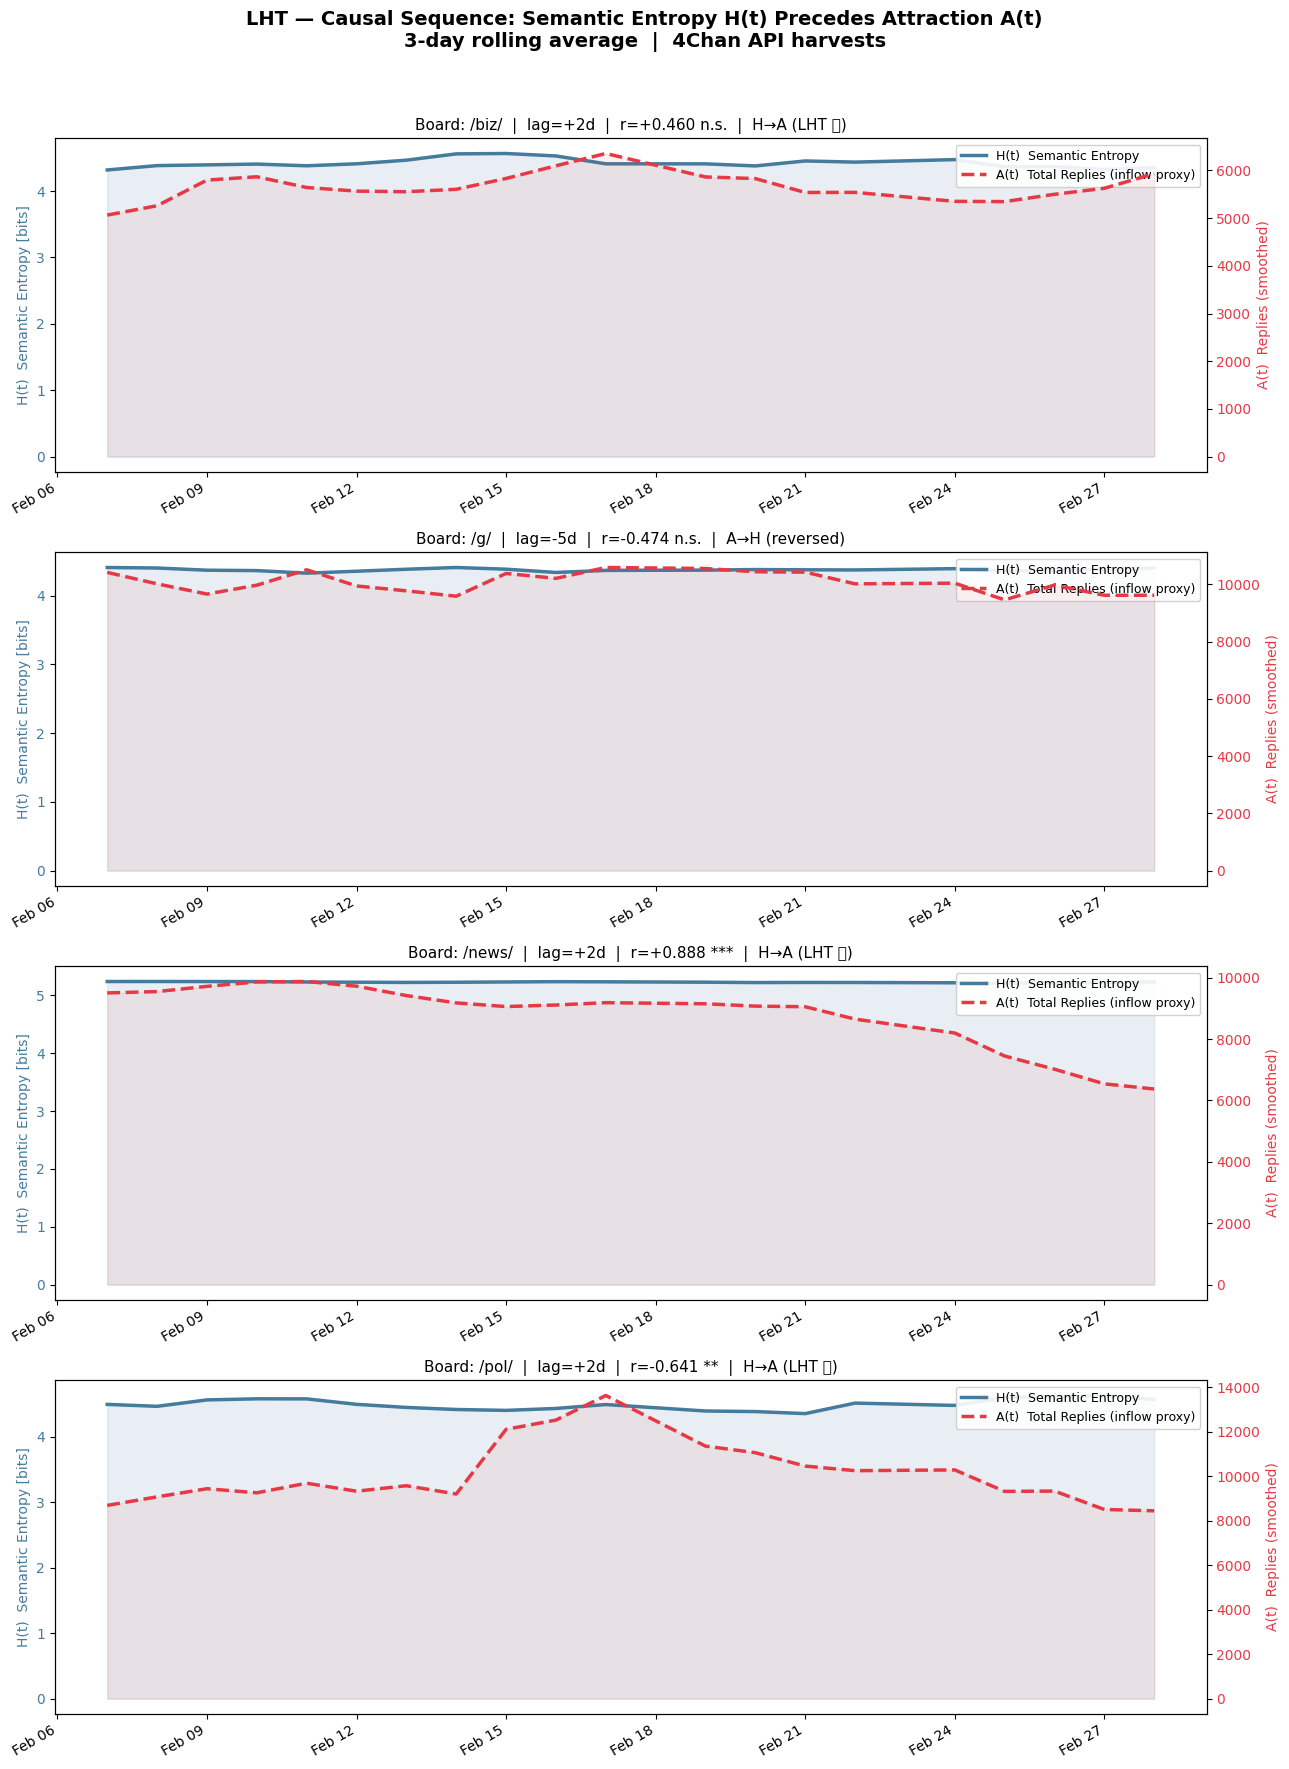

✅  Figure 2 saved.


In [ ]:
# ── FIGURE 2 — CAUSAL SEQUENCE H(t) × A(t) ───────────────────────
if not _has_temporal or df_causal.empty or 'A_smooth' not in df_causal.columns:
    print("⚠️  Figure 2 skipped — no temporal data available.")
else:
    boards_fig = sorted(df_causal['board'].unique()) if 'board' in df_causal.columns else ['all']
    n_b = len(boards_fig)
    fig, axes = plt.subplots(n_b, 1, figsize=(13, 4.5*n_b), sharex=False)
    if n_b == 1: axes = [axes]

    fig.suptitle(
        'LHT — Causal Sequence: Semantic Entropy H(t) Precedes Attraction A(t)\n'
        '3-day rolling average  |  4Chan API harvests',
        fontsize=14, fontweight='bold'
    )

    for ax, board in zip(axes, boards_fig):
        grp = (df_causal[df_causal['board'] == board] if 'board' in df_causal.columns
               else df_causal).sort_values('date').dropna(subset=['H_smooth','A_smooth'])
        if len(grp) < 3:
            ax.set_visible(False); continue

        ax2 = ax.twinx()
        ax.plot(grp['date'], grp['H_smooth'], color='#457B9D',
                lw=2.5, label='H(t)  Semantic Entropy')
        ax.fill_between(grp['date'], grp['H_smooth'], alpha=0.12, color='#457B9D')
        ax2.plot(grp['date'], grp['A_smooth'], color='#E63946',
                 lw=2.5, linestyle='--', label='A(t)  Total Replies (inflow proxy)')
        ax2.fill_between(grp['date'], grp['A_smooth'], alpha=0.07, color='#E63946')

        if len(df_xcorr):
            row = df_xcorr[df_xcorr['board'] == board]
            if len(row):
                lag = row['best_lag_days'].values[0]
                r   = row['r'].values[0]
                sig = row['sig'].values[0]
                itp = row['interpretation'].values[0]
                ax.set_title(f'Board: {board}  |  lag={lag:+d}d  |  r={r:+.3f} {sig}  |  {itp}',
                             fontsize=11)
        else:
            ax.set_title(f'Board: {board}', fontsize=11)

        ax.set_ylabel('H(t)  Semantic Entropy [bits]', color='#457B9D', fontsize=10)
        ax2.set_ylabel('A(t)  Replies (smoothed)',      color='#E63946', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax.tick_params(axis='y', labelcolor='#457B9D')
        ax2.tick_params(axis='y', labelcolor='#E63946')
        l1,lb1 = ax.get_legend_handles_labels()
        l2,lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, loc='upper right', fontsize=9, framealpha=0.9)

    plt.tight_layout(rect=[0,0,1,0.96])
    for ext in ('pdf','png'):
        plt.savefig(f'{MYDRIVE}/LHT_Fig2_CausalSequence.{ext}',
                    dpi=150, bbox_inches='tight')
    plt.show()
    print("✅  Figure 2 saved.")

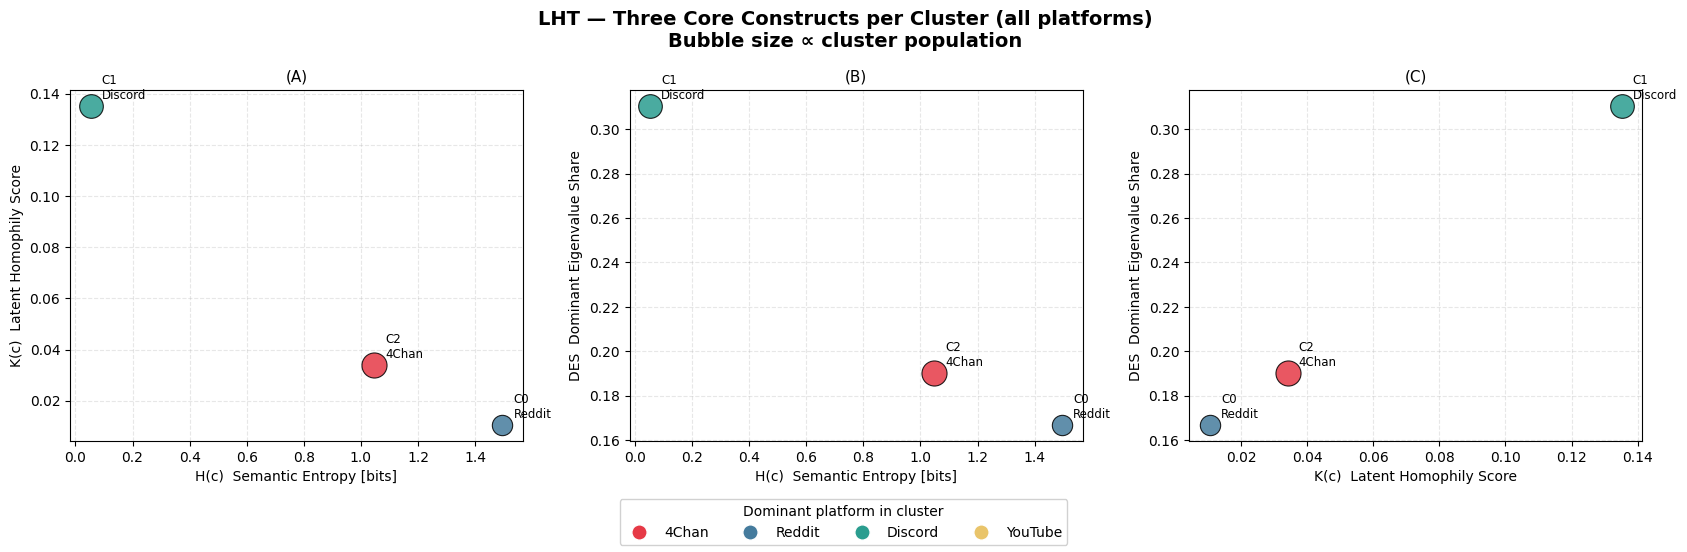

✅  Figure 3 saved.


In [ ]:
# ── FIGURE 3 — LHT THREE CONSTRUCTS SCATTER ───────────────────────
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle(
    'LHT — Three Core Constructs per Cluster (all platforms)\n'
    'Bubble size ∝ cluster population',
    fontsize=14, fontweight='bold'
)

PANELS = [
    ('H(c) [bits]', 'K(c)',
     'H(c)  Semantic Entropy [bits]', 'K(c)  Latent Homophily Score', '(A)'),
    ('H(c) [bits]', 'DES',
     'H(c)  Semantic Entropy [bits]', 'DES  Dominant Eigenvalue Share', '(B)'),
    ('K(c)', 'DES',
     'K(c)  Latent Homophily Score',  'DES  Dominant Eigenvalue Share', '(C)'),
]

for ax, (xc, yc, xl, yl, lbl) in zip(axes, PANELS):
    for _, row in df_summary.iterrows():
        color = PLATFORM_COLORS.get(row['Platform'], '#888888')
        xv, yv = row[xc], row[yc]
        if pd.isna(xv) or pd.isna(yv): continue
        ax.scatter(xv, yv, c=color, s=row['N']/4,
                   alpha=0.85, edgecolors='k', linewidth=0.8, zorder=3)
        ax.annotate(f"C{int(row['Cluster'])}\n{row['Platform']}",
                    (xv, yv), textcoords='offset points',
                    xytext=(8,5), fontsize=8.5, zorder=4)
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.set_title(lbl, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')

legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=11, label=p)
    for p, c in PLATFORM_COLORS.items()
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           framealpha=0.9, fontsize=10,
           title='Dominant platform in cluster', title_fontsize=10)
plt.tight_layout(rect=[0, 0.09, 1, 1])
for ext in ('pdf','png'):
    plt.savefig(f'{MYDRIVE}/LHT_Fig3_Constructs.{ext}',
                dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 3 saved.")

## PHASE 8 — Final Analysis: LHT Empirical Verdict

In [ ]:
# ── 8  STRUCTURED EMPIRICAL CONCLUSION ───────────────────────────
SEP  = '=' * 72
SEP2 = '-' * 72

print(SEP)
print('  LATENT HOMOPHILY THEORY (LHT) — EMPIRICAL VERDICT')
print('  Carvalho, A.S. (2025-26) | Paris 1 Panthéon-Sorbonne / PRISM')
print(SEP)

# ── Corpus overview ──────────────────────────────────────────────
print('\n[1] CORPUS OVERVIEW')
print(SEP2)
total = len(META)
for plat, n in META['network'].value_counts().items():
    print(f'  {plat:<12} {n:>5} obs  ({100*n/total:.1f}%)')
print(f'  {"TOTAL":<12} {total:>5}')
print(f'  Clusters: K={META["cluster_macro"].nunique()}')

# ── Claim 1: H(c) differentiates ────────────────────────────────
print('\n[2] CLAIM 1 — Low semantic entropy signals latent homophily')
print(SEP2)
for _, r in df_summary.sort_values('H(c) [bits]', ascending=False).iterrows():
    H = r['H(c) [bits]']
    interp = ('→ HIGH: attraction phase (mixed)'   if H > 1.2 else
              '→ MODERATE: transitional state'       if H > 0.4 else
              '→ LOW: cohesion phase (homophilic)')
    print(f'  Cluster {int(r["Cluster"])} [{r["Platform"]:>8}]  '
          f'H={H:.4f}  VNE={r["VNE"]:.4f}  {interp}')
H_range = df_summary['H(c) [bits]'].max() - df_summary['H(c) [bits]'].min()
verdict1 = 'SUPPORTED' if H_range > 0.3 else 'WEAK'
print(f'\n  ► Entropy range: {H_range:.4f} bits  |  Verdict: {verdict1}')

# ── Claim 2: K(c) > 0 ───────────────────────────────────────────
print('\n[3] CLAIM 2 — Kernel homophily K(c) > 0 in all clusters')
print(SEP2)
for _, r in df_homophily.iterrows():
    sig  = ('***' if r['p_value']<0.001 else '**' if r['p_value']<0.01
            else '*' if r['p_value']<0.05 else 'n.s.')
    icon = '✅' if r['K_homophily'] > 0 else '❌'
    print(f'  {icon} Cluster {int(r["cluster"])} [{r["dominant"]:>8}]  '
          f'K(c)={r["K_homophily"]:+.6f}  p={r["p_value"]:.4f} {sig}')
all_pos = (df_homophily['K_homophily'] > 0).all()
all_sig = (df_homophily['p_value'] < 0.05).all()
verdict2 = ('SUPPORTED' if all_pos and all_sig else
            'PARTIALLY SUPPORTED' if all_pos else 'NOT SUPPORTED')
print(f'\n  ► All K(c)>0: {all_pos}  |  All p<.05: {all_sig}  |  Verdict: {verdict2}')

# ── Claim 3: H(t) → A(t) ────────────────────────────────────────
print('\n[4] CLAIM 3 — H(t) decline precedes A(t) growth')
print(SEP2)
if df_xcorr.empty:
    print('  ⚠️  No temporal data — Claim 3 cannot be evaluated.')
    verdict3 = 'NOT EVALUATED'
else:
    lht_ok = 0
    for _, r in df_xcorr.iterrows():
        icon = '✅' if r['best_lag_days']>0 else '⚠️ ' if r['best_lag_days']==0 else '❌'
        if r['best_lag_days'] > 0: lht_ok += 1
        print(f'  {icon} Board {r["board"]:6}  lag={r["best_lag_days"]:+2d}d  '
              f'r={r["r"]:+.4f} {r["sig"]}  |  {r["interpretation"]}')
    frac = lht_ok / len(df_xcorr)
    verdict3 = ('SUPPORTED' if frac >= 0.75 else
                'PARTIALLY SUPPORTED' if frac >= 0.5 else 'NOT SUPPORTED')
    print(f'\n  ► Boards confirming H→A: {lht_ok}/{len(df_xcorr)} ({100*frac:.0f}%)  |  Verdict: {verdict3}')

# ── DES authenticity ─────────────────────────────────────────────
print('\n[5] DOMINANT EIGENVALUE SHARE — Cluster authenticity screening')
print(SEP2)
for _, r in df_des.sort_values('DES', ascending=False).iterrows():
    q = ('🟢 Genuine' if r['DES']>0.15 else '🟡 Moderate' if r['DES']>0.05 else '🔴 Artefact?')
    print(f'  Cluster {int(r["cluster"])} [{r["dominant"]:>8}]  DES={r["DES"]:.4f}  H={r["H_platform"]:.4f}  {q}')
if len(df_des) >= 3:
    rho, pv = spearmanr(df_des['DES'], -df_des['H_platform'])
    print(f'\n  ► Spearman ρ(DES, −H) = {rho:+.4f}  p={pv:.4f}')
    print(f'     LHT predicts ρ > 0  (lower entropy → higher eigenvalue share)')

# ── YouTube signal ───────────────────────────────────────────────
print('\n[6] YOUTUBE — Cross-Platform Leakage Signal')
print(SEP2)
yt_rows = META[META['network']=='YouTube']
if len(yt_rows) == 0:
    print('  ⚠️  YouTube not loaded — re-run Phase 2-B with correct paths.')
else:
    dist = yt_rows['cluster_macro'].value_counts(normalize=True)
    print(f'  YouTube observations: {len(yt_rows)}')
    for cid, frac in dist.items():
        dom = META[META['cluster_macro']==cid]['network'].value_counts().index[0]
        print(f'    Cluster {cid} [{dom:>8}]  {100*frac:.1f}%')
    top_cid = dist.index[0]
    top_dom = META[META['cluster_macro']==top_cid]['network'].value_counts().index[0]
    print(f'\n  ► YouTube clusters predominantly into Cluster {top_cid} (dom: {top_dom})')
    if top_dom in ('4Chan','Reddit'):
        print(f'     → Supports LHT cross-platform entropy collapse hypothesis.')

# ── Global verdict ───────────────────────────────────────────────
print('\n' + SEP)
print('  GLOBAL VERDICT')
print(SEP)
verdicts = [
    ('H(c) entropy differentiation',  verdict1),
    ('K(c) latent homophily > 0',      verdict2),
    ('H(t) → A(t) causal sequence',    verdict3),
]
for claim, verd in verdicts:
    icon = '✅' if verd=='SUPPORTED' else '⚠️ ' if 'PARTIAL' in verd else ('🔲' if 'EVALUATED' in verd else '❌')
    print(f'  {icon} {claim:<42} {verd}')

n_supp = sum(1 for _,v in verdicts if v=='SUPPORTED')
n_part = sum(1 for _,v in verdicts if 'PARTIAL' in v)
overall = ('ALL THREE LHT CLAIMS SUPPORTED — strong basis for publication.' if n_supp==3 else
           'LHT PARTIALLY CONFIRMED — strengthen causal identification.' if n_supp+n_part>=2 else
           'LHT CLAIMS REQUIRE REVISION — revisit operationalisation.')
print(f'\n  ► {overall}')

print('\n  Recommended next steps:')
print('  1. Increase N_PERM → 1000 (Phase 4.2) for final paper p-values.')
print('  2. Run Granger causality (statsmodels VAR) for A(t) ~ H(t-k).')
print('  3. Extend 4Chan harvest to ≥ 6 weeks for robust cross-correlation.')
print('  4. Apply LHT framework to EU AI Act HR-system audit dataset (Paper 2).')

# ── Export LaTeX table ───────────────────────────────────────────
latex = df_summary.to_latex(
    index=False, float_format='%.4f',
    caption='LHT Cluster Analysis: Semantic Entropy, Latent Homophily, and DES',
    label='tab:lht_results'
)
tex_path = os.path.join(MYDRIVE, 'LHT_Table1_Results.tex')
with open(tex_path, 'w') as f: f.write(latex)
df_summary.to_csv(os.path.join(MYDRIVE, 'LHT_Table1_Results.csv'), index=False)
print(f'\n✅  Table exported: {tex_path}')
print(SEP)

  LATENT HOMOPHILY THEORY (LHT) — EMPIRICAL VERDICT
  Carvalho, A.S. (2025-26) | Paris 1 Panthéon-Sorbonne / PRISM

[1] CORPUS OVERVIEW
------------------------------------------------------------------------
  4Chan         1200 obs  (36.1%)
  Discord       1200 obs  (36.1%)
  Reddit         845 obs  (25.4%)
  YouTube         77 obs  (2.3%)
  TOTAL         3322
  Clusters: K=3

[2] CLAIM 1 — Low semantic entropy signals latent homophily
------------------------------------------------------------------------
  Cluster 0 [  Reddit]  H=1.4958  VNE=5.2368  → HIGH: attraction phase (mixed)
  Cluster 2 [   4Chan]  H=1.0477  VNE=5.2949  → MODERATE: transitional state
  Cluster 1 [ Discord]  H=0.0531  VNE=4.5493  → LOW: cohesion phase (homophilic)

  ► Entropy range: 1.4427 bits  |  Verdict: SUPPORTED

[3] CLAIM 2 — Kernel homophily K(c) > 0 in all clusters
------------------------------------------------------------------------
  ✅ Cluster 0 [  Reddit]  K(c)=+0.010407  p=0.0080 **
  ✅ Clust